# Collocation and unstable single shooting

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pierrelux/rlbook/blob/main/lab/notebooks/09_collocation_and_unstable_shooting.ipynb)

Two optimizers can solve the same discretized control problem yet behave very
differently as the horizon grows. This 60-minute session first isolates that
effect in a scalar system, then transfers it to a pendulum near upright.

By the end, you should be able to:

1. Obtain single shooting by eliminating the states from midpoint collocation.
2. Derive how an early control affects a distant state.
3. Compare optimization methods using costs, reference solutions, and defects.
4. Distinguish easier optimization from robust open-loop execution.

Allow 40 minutes for the scalar experiment and 20 for the pendulum. The
[previous notebook](08_collocation_two_formulations.ipynb) introduces the
collocation equations; [notebook 05](05_finite_horizon_lqr.ipynb) introduces the
Riccati recursion. All code needed here is included below.

Run cells in order in Colab, local Jupyter, or the browser lab's **Python
(XPython)** kernel. NumPy, SciPy, and Matplotlib are the only dependencies.
The horizon sweeps and pendulum solves run on a CPU. Browser runtimes can be
slower; each sweep prints progress. No installation or repository checkout is needed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

np.set_printoptions(precision=5, suppress=True)
plt.rcParams.update({
    'figure.figsize': (8, 3.3), 'figure.dpi': 110,
    'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False,
    'legend.frameon': False, 'lines.linewidth': 2,
    'axes.prop_cycle': plt.cycler(color=['#0072B2', '#D55E00', '#009E73', '#CC79A7']),
})

import time
import scipy
print('NumPy', np.__version__, '| SciPy', scipy.__version__)

NumPy 2.3.1 | SciPy 1.16.1


## 1. Keep the discrete problem fixed (40 minutes)

Consider an unstable scalar system and a quadratic objective:

$$
\dot x=ax+u,\quad x(0)=1,\qquad
J=\frac12\int_0^T(x^2+0.1u^2)\,dt+\frac12x(T)^2.
$$

Set a = 1. On each interval of width h = 0.1, hold u<sub>k</sub> constant and use
one midpoint collocation node. The state polynomial is linear, so its midpoint
is m<sub>k</sub> = (x<sub>k</sub> + x<sub>k+1</sub>)/2. The finite problem is

$$
x_{k+1}-x_k=h(am_k+u_k),\qquad
J_h=\frac h2\sum_{k=0}^{N-1}(m_k^2+0.1u_k^2)+\frac12x_N^2.
$$

This is the preceding notebook's integral form with A = [½], b = [1], after
eliminating the midpoint stage state. Its differentiation form has
E = [½, ½] and D = [−1, 1] and gives exactly the same defect.

**Collocation** chooses both states and controls subject to these local defects.
**Single shooting** solves each defect for the next state and chooses only controls:

$$
x_{k+1}=\alpha x_k+\beta u_k,\qquad
\alpha=\frac{1+ah/2}{1-ah/2},\quad \beta=\frac{h}{1-ah/2}.
$$

Both use this same midpoint approximation, objective, and time grid. We require
|ah/2| &lt; 1 in this experiment so the step is well away from its singularity.

In [2]:
def scalar_problem(T, a=1.0, h=0.1, r=0.1):
    N = int(round(T/h))
    if N < 1 or not np.isclose(N*h, T) or abs(a*h/2) >= 1:
        raise ValueError('Use a positive integer number of steps and |a*h/2| < 1.')
    alpha, beta = (1+a*h/2)/(1-a*h/2), h/(1-a*h/2)

    def rollout(u):
        x = np.empty(N+1)
        x[0] = 1.0
        for k in range(N):
            # Equivalent to alpha*x+beta*u, but preserves a*x+u=0 exactly.
            x[k+1] = x[k]+h*(a*x[k]+u[k])/(1-a*h/2)
        return x

    def cost_partials(x, u):
        midpoint = (x[:-1]+x[1:])/2
        value = h/2*(midpoint @ midpoint+r*(u @ u))+x[-1]**2/2
        gx = np.zeros(N+1)
        gx[:-1] += h*midpoint/2
        gx[1:] += h*midpoint/2
        gx[-1] += x[-1]
        gu = h*r*u
        return value, gx, gu

    def shooting_value_gradient(u):
        x = rollout(u)
        value, gx, gu = cost_partials(x, u)
        gradient = gu.copy()
        adjoint = gx[-1]
        for k in range(N-1, -1, -1):
            gradient[k] += beta*adjoint
            adjoint = gx[k]+alpha*adjoint
        return value, gradient

    def collocation_value_gradient(z):
        value, gx, gu = cost_partials(z[:N+1], z[N+1:])
        return value, np.concatenate([gx, gu])

    def defects(z):
        x, u = z[:N+1], z[N+1:]
        midpoint = (x[:-1]+x[1:])/2
        return np.r_[x[0]-1, x[1:]-x[:-1]-h*(a*midpoint+u)]

    J = np.zeros((N+1, 2*N+1))
    J[0, 0] = 1
    k = np.arange(N)
    J[k+1, k] = -1-h*a/2
    J[k+1, k+1] = 1-h*a/2
    J[k+1, N+1+k] = -h
    return dict(N=N, T=T, a=a, h=h, r=r, alpha=alpha, beta=beta,
                rollout=rollout, cost=cost_partials, shoot=shooting_value_gradient,
                collocate=collocation_value_gradient, defects=defects, jacobian=J)

The shooting gradient is a backward chain rule. If g<sub>k</sub><sup>x</sup> and g<sub>k</sub><sup>u</sup> are
the objective's partial derivatives with all states temporarily independent,
then λ<sub>N</sub> = g<sub>N</sub><sup>x</sup> and

$$
\nabla_{u_k}J_h=g^u_k+\beta\lambda_{k+1},\qquad
\lambda_k=g^x_k+\alpha\lambda_{k+1}.
$$

The same multiplications by α appear in the forward sensitivity.
An early control passes through more of them:

$$
\frac{\partial x_N}{\partial u_j}=\beta\alpha^{N-1-j}.
$$

For a>0, α > 1. The physical horizon grows while the time step stays
fixed, so the amplification grows even though the number of optimization
variables grows only linearly. This is a conditioning issue associated with
the horizon, distinct from the curse of state-space dimensionality.

**Predict:** if a changes from 1 to −1, will the first control's influence
on the terminal state grow or decay? Does a smaller decision vector necessarily
give a better-conditioned optimization problem?

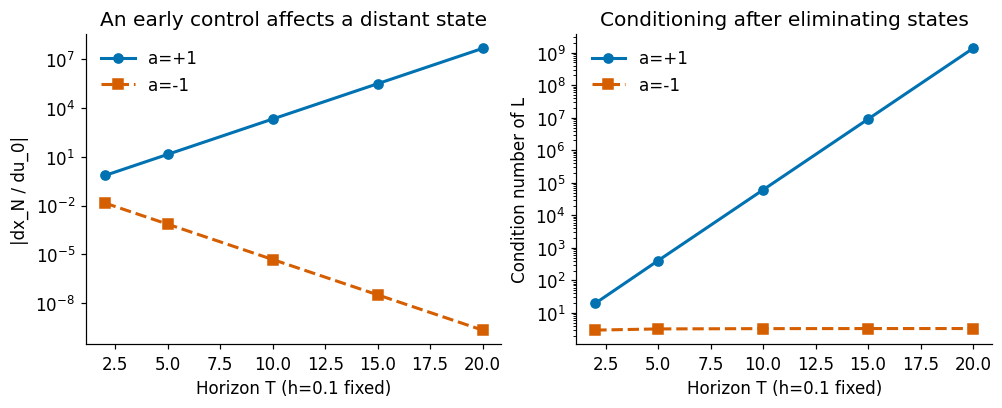

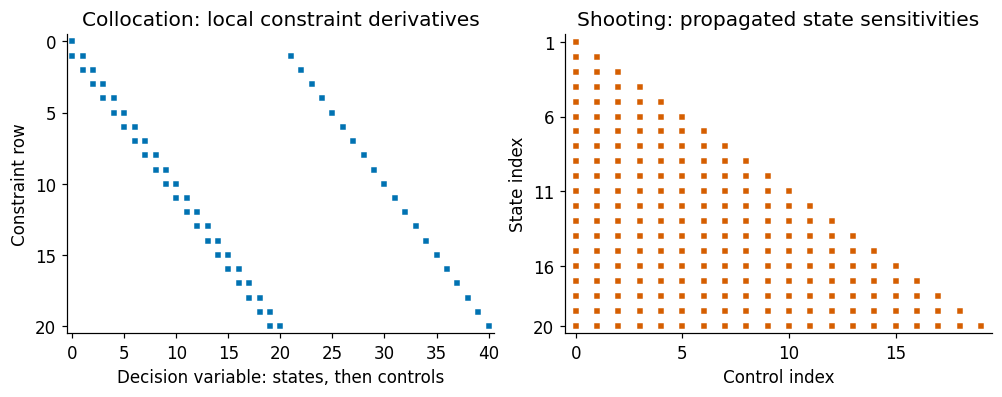

In [3]:
def shooting_sensitivity(problem):
    N, alpha, beta = problem['N'], problem['alpha'], problem['beta']
    S = np.zeros((N+1, N))
    for k in range(N):
        S[k+1] = alpha*S[k]
        S[k+1, k] += beta
    return S


horizons = np.array([2, 5, 10, 15, 20], dtype=float)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), constrained_layout=True)
for a, style in [(1, 'o-'), (-1, 's--')]:
    sensitivity, condition = [], []
    for T in horizons:
        problem = scalar_problem(T, a=a)
        S = shooting_sensitivity(problem)
        sensitivity.append(abs(S[-1, 0]))
        # J_h(u) = 1/2 ||L*u + c||^2. Stack state, control, terminal terms.
        midpoint_S = (S[:-1]+S[1:])/2
        L = np.vstack([np.sqrt(problem['h'])*midpoint_S,
                       np.sqrt(problem['h']*problem['r'])*np.eye(problem['N']), S[-1:]])
        condition.append(np.linalg.cond(L))
    axes[0].semilogy(horizons, sensitivity, style, label=f'a={a:+d}')
    axes[1].semilogy(horizons, condition, style, label=f'a={a:+d}')
axes[0].set(xlabel='Horizon T (h=0.1 fixed)', ylabel='|dx_N / du_0|', title='An early control affects a distant state')
axes[1].set(xlabel='Horizon T (h=0.1 fixed)', ylabel='Condition number of L', title='Conditioning after eliminating states')
for ax in axes:
    ax.legend()
plt.show()

problem = scalar_problem(2)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), constrained_layout=True)
axes[0].spy(problem['jacobian'], markersize=3, aspect='auto', origin='upper', color='#0072B2')
axes[0].set(title='Collocation: local constraint derivatives', xlabel='Decision variable: states, then controls', ylabel='Constraint row')
axes[1].spy(shooting_sensitivity(problem)[1:], markersize=3, aspect='auto', origin='upper', color='#D55E00')
axes[1].set(title='Shooting: propagated state sensitivities', xlabel='Control index', ylabel='State index')
axes[1].set_yticks([0, 5, 10, 15, 19], labels=[1, 6, 11, 16, 20])
for ax in axes:
    ax.xaxis.tick_bottom()
plt.show()

The plotted condition number uses the square-root objective matrix L.
In exact arithmetic the condensed Hessian is L<sup>⊤</sup>L, with condition
number κ(L)². Forming it explicitly can already lose small directions
in floating point, so we inspect L instead. The sparse local derivative
pattern alone is not a theorem that every collocation problem is well conditioned.

### A reference solution to the same discrete problem

The scalar problem is linear-quadratic. A Riccati recursion provides a reference
without asking a generic optimizer to solve it. The midpoint cost introduces
a state-control cross term, which must be retained for a fair comparison.
Writing m<sub>k</sub> = d x<sub>k</sub> + e u<sub>k</sub>, with d = (1 + α)/2, e = β/2, gives

$$
Q=hd^2,\quad S=hde,\quad R=h(e^2+0.1),\qquad
\ell_k=\tfrac12(Qx_k^2+2Sx_ku_k+Ru_k^2).
$$

For P<sub>N</sub> = 1, minimizing the quadratic in u<sub>k</sub> gives

$$
K_k=\frac{S+\alpha\beta P_{k+1}}{R+\beta^2P_{k+1}},\quad
u_k=-K_kx_k,\quad
P_k=Q+\alpha^2P_{k+1}-(S+\alpha\beta P_{k+1})K_k.
$$

The recursion below computes this reference from scratch. Its feedback rollout
also avoids long open-loop cancellation when constructing the reference states.

In [4]:
def scalar_riccati(problem):
    N = problem['N']
    alpha, beta, h, r = (problem[key] for key in ['alpha', 'beta', 'h', 'r'])
    d, e = (1+alpha)/2, beta/2
    Q, S, R = h*d*d, h*d*e, h*(e*e+r)
    P, gains = np.empty(N+1), np.empty(N)
    P[-1] = 1.0
    for k in range(N-1, -1, -1):
        cross = S+alpha*beta*P[k+1]
        gains[k] = cross/(R+beta*beta*P[k+1])
        P[k] = Q+alpha*alpha*P[k+1]-cross*gains[k]
    x, u = np.empty(N+1), np.empty(N)
    x[0] = 1
    for k in range(N):
        u[k] = -gains[k]*x[k]
        x[k+1] = (alpha-beta*gains[k])*x[k]
    value = problem['cost'](x, u)[0]
    np.testing.assert_allclose(value, P[0]/2, atol=1e-12)
    return dict(x=x, u=u, cost=value, gains=gains)


def solve_scalar(T, a=1.0, maxiter=1000):
    problem = scalar_problem(T, a=a)
    N = problem['N']
    # Both methods start at the same feasible equilibrium x=1, u=-a.
    u0 = np.full(N, -a)
    x0 = problem['rollout'](u0)
    options = {'ftol': 1e-10, 'maxiter': maxiter}
    results = {}
    start = time.perf_counter()
    shooting = minimize(problem['shoot'], u0, jac=True, method='SLSQP', options=options)
    results['shooting'] = dict(result=shooting, x=problem['rollout'](shooting.x), u=shooting.x,
                               seconds=time.perf_counter()-start)
    start = time.perf_counter()
    collocation = minimize(problem['collocate'], np.r_[x0, u0], jac=True, method='SLSQP',
                           constraints={'type': 'eq', 'fun': problem['defects'],
                                        'jac': lambda z: problem['jacobian']}, options=options)
    results['collocation'] = dict(result=collocation, x=collocation.x[:N+1], u=collocation.x[N+1:],
                                  seconds=time.perf_counter()-start)
    reference = scalar_riccati(problem)
    for run in results.values():
        run['cost'] = problem['cost'](run['x'], run['u'])[0]
        run['cost_error'] = abs(run['cost']-reference['cost'])/max(abs(reference['cost']), 1e-15)
        run['control_error'] = np.max(np.abs(run['u']-reference['u']))
        run['defect'] = np.max(np.abs(problem['defects'](np.r_[run['x'], run['u']])))
        run['replay_error'] = np.max(np.abs(problem['rollout'](run['u'])-run['x']))
    return dict(problem=problem, reference=reference, runs=results)

**Predict before the sweep:** which horizon first produces noticeable difficulty?
Write down a prediction, then inspect the cost error as well as the solver status.

Both formulations receive exact derivatives, the same feasible initial
trajectory, and the same SLSQP settings. There are no deliberately poor
finite-difference gradients or different integrators in this comparison.
SLSQP uses dense linear algebra; the sparsity plot explains locality, but this
small demo does not benchmark a sparse optimization solver.

In [5]:
scalar_runs = {}
print(' a   T  method        success  iter    relative cost error    max defect   seconds')
for a in [1.0, -1.0]:
    for T in horizons:
        experiment = solve_scalar(T, a=a)
        scalar_runs[a, T] = experiment
        for method, run in experiment['runs'].items():
            result = run['result']
            print(f'{a:+.0f}  {T:2.0f}  {method:12s}  {str(result.success):5s}  {result.nit:4d}'
                  f'      {run["cost_error"]:12.3e}    {run["defect"]:10.2e}  {run["seconds"]:7.2f}')
            if not result.success:
                print('    Solver message:', result.message)

 a   T  method        success  iter    relative cost error    max defect   seconds
+1   2  shooting      True     22         4.570e-10      5.55e-17     0.00
+1   2  collocation   True     23         1.268e-10      2.78e-17     0.00
+1   5  shooting      True     53         2.775e-10      2.78e-17     0.00
+1   5  collocation   True     47         2.043e-09      2.78e-17     0.02
+1  10  shooting      True     53         4.263e-09      5.55e-17     0.01
+1  10  collocation   True     57         1.371e-09      1.11e-16     0.17


+1  15  shooting      True     60         1.716e-09      8.33e-17     0.02
+1  15  collocation   True     58         4.255e-09      5.55e-17     0.52


+1  20  shooting      False     2         2.058e+13      2.33e-10     0.00
    Solver message: Rank-deficient equality constraint subproblem HFTI
+1  20  collocation   True     58         4.700e-09      5.55e-17     1.36
-1   2  shooting      True     31         7.923e-10      2.78e-17     0.00
-1   2  collocation   True     24         1.871e-10      5.55e-17     0.00
-1   5  shooting      True     39         1.787e-08      1.11e-16     0.00
-1   5  collocation   True     31         3.274e-09      5.55e-17     0.01
-1  10  shooting      True     47         5.297e-09      8.33e-17     0.01
-1  10  collocation   True     52         2.005e-09      5.55e-17     0.15


-1  15  shooting      True     56         2.109e-09      1.39e-17     0.01
-1  15  collocation   True     52         6.024e-09      5.55e-17     0.49


-1  20  shooting      True     59         2.332e-09      5.55e-17     0.02
-1  20  collocation   True     52         6.035e-09      5.55e-17     1.09


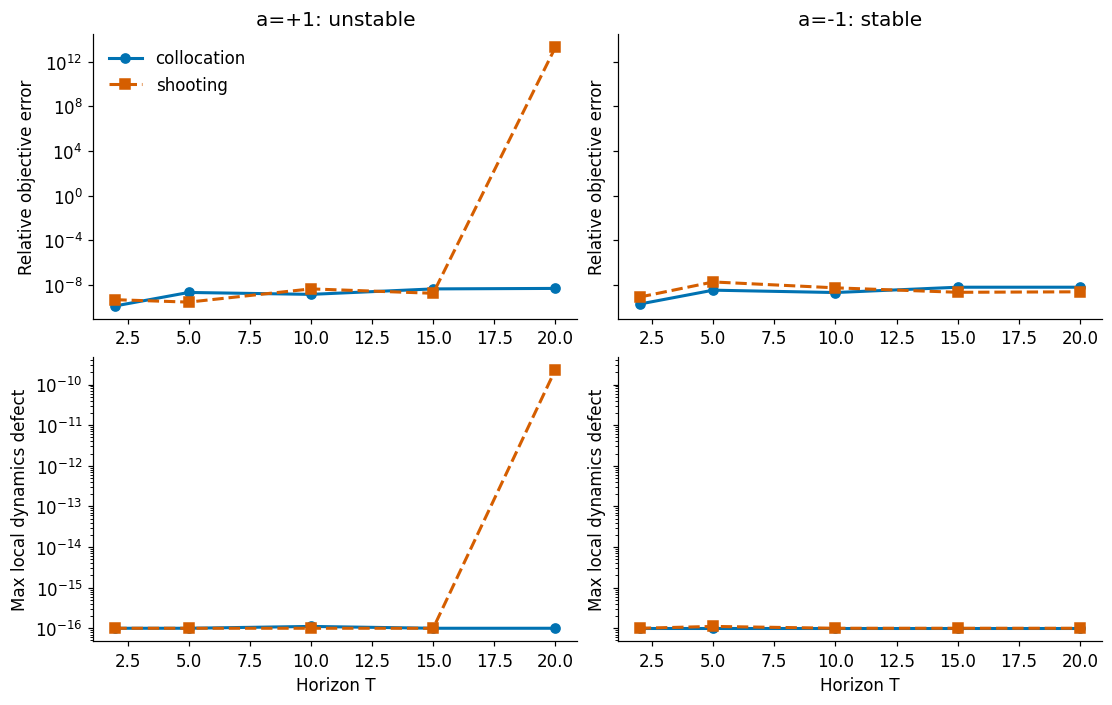

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6.3), constrained_layout=True, sharey='row')
for column, a in enumerate([1.0, -1.0]):
    for method, style in [('collocation', 'o-'), ('shooting', 's--')]:
        runs = [scalar_runs[a, T]['runs'][method] for T in horizons]
        axes[0, column].semilogy(horizons, [max(v['cost_error'], 1e-15) for v in runs], style, label=method)
        axes[1, column].semilogy(horizons, [max(v['defect'], 1e-16) for v in runs], style, label=method)
    axes[0, column].set(title=f'a={a:+.0f}: ' + ('unstable' if a > 0 else 'stable'), ylabel='Relative objective error')
    axes[1, column].set(xlabel='Horizon T', ylabel='Max local dynamics defect')
axes[0, 0].legend()
plt.show()

The defect checks the returned states against the discrete dynamics. Shooting's
states satisfy that recurrence by construction, even when its controls are far
from optimal. A small defect therefore does not imply a small objective error.
Values below 10<sup>−15</sup> (cost) or 10<sup>−16</sup> (defects) are placed at those plot
floors so exact zeros can appear on log axes.

The failure threshold and solver message can change with SciPy versions or
hardware. The sensitivity calculation explains the mechanism independently of
that threshold. At shorter horizons, shooting may be cheaper; collocation
introduces more variables and more work per iteration.

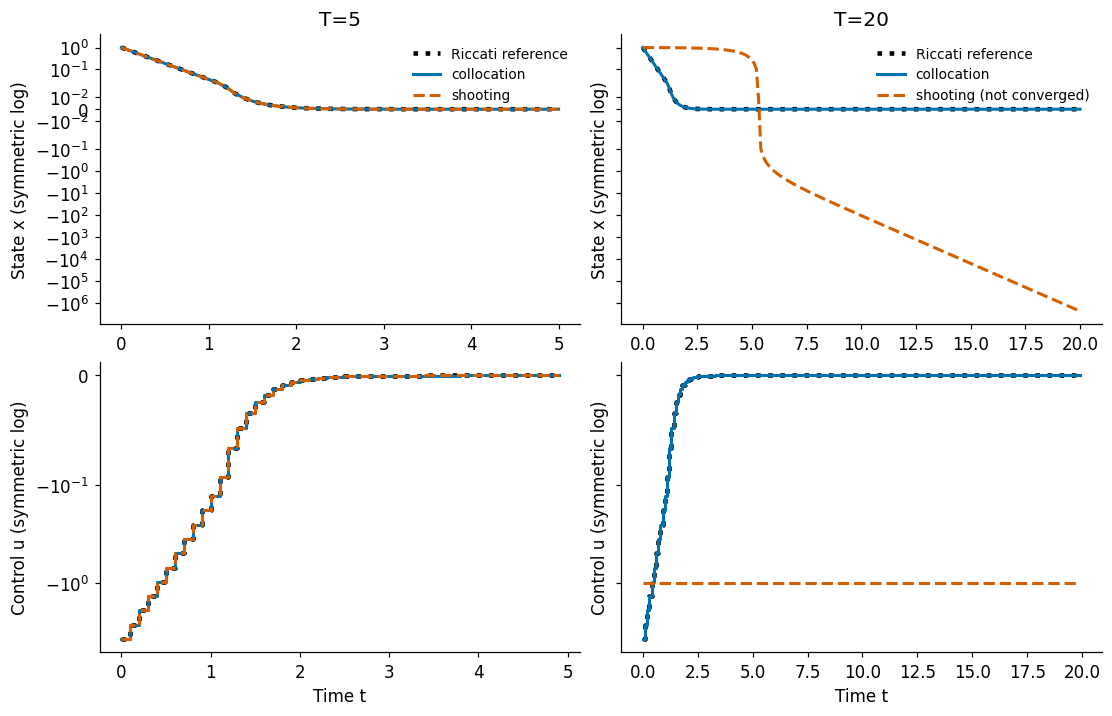

Collocation matches the Riccati reference; short-horizon shooting agrees.


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6.4), constrained_layout=True, sharey='row')
for column, T in enumerate([5.0, 20.0]):
    experiment = scalar_runs[1.0, T]
    mesh = np.arange(experiment['problem']['N']+1)*0.1
    ref = experiment['reference']
    axes[0, column].plot(mesh, ref['x'], ':', color='black', linewidth=3, label='Riccati reference')
    axes[1, column].step(mesh[:-1], ref['u'], where='post', color='black', linestyle=':', linewidth=3)
    for method, style in [('collocation', '-'), ('shooting', '--')]:
        run = experiment['runs'][method]
        label = method + ('' if run['result'].success else ' (not converged)')
        axes[0, column].plot(mesh, run['x'], style, label=label)
        axes[1, column].step(mesh[:-1], run['u'], where='post', linestyle=style)
    axes[0, column].set(title=f'T={T:g}', ylabel='State x (symmetric log)')
    axes[1, column].set(xlabel='Time t', ylabel='Control u (symmetric log)')
    axes[0, column].set_yscale('symlog', linthresh=0.02)
    axes[1, column].set_yscale('symlog', linthresh=0.1)
    axes[0, column].legend(fontsize=9)
plt.show()

for a in [1.0, -1.0]:
    for T in horizons:
        experiment = scalar_runs[a, T]
        collocation = experiment['runs']['collocation']
        assert collocation['result'].success
        assert collocation['defect'] < 1e-8
        assert collocation['cost_error'] < 1e-6
        assert collocation['control_error'] < 1e-3
    # Agreement is asserted in the well-conditioned short-horizon comparison.
    assert scalar_runs[a, 2.0]['runs']['shooting']['cost_error'] < 1e-6
print('Collocation matches the Riccati reference; short-horizon shooting agrees.')

The symmetric-log axes keep both near-zero trajectories and a potentially
large nonconverged iterate visible. They are linear close to zero and
logarithmic farther away; do not read their slopes as physical rates.

**Modify:** change `a` in `solve_scalar`, keeping h fixed. Alternatively,
change `maxiter` for both methods. Explain which observations reflect
sensitivity and which depend on an optimizer's stopping rules. Collocation
does not eliminate the physical sensitivity to control or initial-state errors.

## 2. Transfer the experiment to a pendulum (20 minutes)

For a directly actuated pendulum, measure angle θ from upright and use
dimensionless time and torque:

$$
\dot\theta=\omega,\qquad \dot\omega=\sin\theta+u,\qquad
(\theta_0,\omega_0)=(0.2,0),\quad |u_k|\le2.
$$

Near upright, sin θ ≈ θ, so perturbations have an unstable
mode. Both methods start at the same tilted equilibrium:
θ<sub>k</sub> = 0.2, ω<sub>k</sub> = 0, u<sub>k</sub> = −sin(0.2). Starting from equilibrium
keeps the unstable mechanism visible without an initial uncontrolled fall.

With m<sub>k</sub> = (x<sub>k</sub> + x<sub>k+1</sub>)/2, retain midpoint dynamics and minimize

$$
J_h=\frac h2\sum_k\left(m_{k,\theta}^2+0.1m_{k,\omega}^2+0.01u_k^2\right)
+\frac12(10\theta_N^2+\omega_N^2).
$$

Use h = 0.1 and compare T = 4 with T = 12. This is a balancing task,
not swing-up. **Predict:** will the same controls keep the continuous pendulum
on a perfectly feasible discrete trajectory over an arbitrarily long horizon?

In [8]:
def pendulum_f(x, u):
    return np.array([x[1], np.sin(x[0])+u])


def pendulum_fx(x):
    return np.array([[0.0, 1.0], [np.cos(x[0]), 0.0]])


def midpoint_step(x, u, h):
    """Solve the implicit midpoint step explicitly with Newton's method."""
    if not 0 < h < 2:
        raise ValueError('Use 0 < h < 2 for the unique angle root in this example.')
    theta, omega = x
    next_theta = theta+h*omega
    for _ in range(20):
        mid_theta = (theta+next_theta)/2
        residual = next_theta-theta-h*omega-h*h/2*(np.sin(mid_theta)+u)
        derivative = 1-h*h/4*np.cos(mid_theta)
        correction = residual/derivative
        next_theta -= correction
        if abs(correction) < 1e-13:
            break
    else:
        raise RuntimeError('Midpoint Newton iteration did not converge.')
    next_omega = omega+h*(np.sin((theta+next_theta)/2)+u)
    return np.array([next_theta, next_omega])


def pendulum_rollout(u, h=0.1):
    x = np.empty((len(u)+1, 2))
    x[0] = [0.2, 0]
    for k, control in enumerate(u):
        x[k+1] = midpoint_step(x[k], control, h)
    return x

Eliminating the next angular velocity leaves one nonlinear angle equation:

$$
\theta_{k+1}-\theta_k-h\omega_k-
\frac{h^2}{2}\left[\sin\frac{\theta_k+\theta_{k+1}}2+u_k\right]=0.
$$

For h&lt; 2, its derivative satisfies

$$
1-\frac{h^2}{4}\cos((\theta_k+\theta_{k+1})/2)>0,
$$

so the root is unique. The code checks convergence rather than
silently accepting an inaccurate integration step.

To differentiate the implicit step, write A<sub>k</sub> = f<sub>x</sub>(m<sub>k</sub>, u<sub>k</sub>),
B = (0, 1)<sup>⊤</sup>, and M<sub>k</sub> = I − (h/2)A<sub>k</sub>. Differentiating the midpoint
defect gives

$$
d_{x_k}=-I-\tfrac h2A_k,\quad d_{x_{k+1}}=M_k,\quad d_{u_k}=-hB.
$$

Solving these equations gives the shooting-step derivatives
C<sub>k</sub> = M<sub>k</sub><sup>−1</sup>(I + (h/2)A<sub>k</sub>) and D<sub>k</sub> = M<sub>k</sub><sup>−1</sup>hB.
The implementation uses linear solves, not explicit matrix inverses. Its
backward gradient recursion is the vector version of the scalar one above.

In [9]:
def pendulum_problem(T, h=0.1):
    N = int(round(T/h))
    if N < 1 or not np.isclose(N*h, T) or not 0 < h < 2:
        raise ValueError('Use a positive integer number of steps with 0 < h < 2.')
    nx = 2*(N+1)
    Q, Qf, r = np.array([1.0, 0.1]), np.array([10.0, 1.0]), 0.01
    identity, B = np.eye(2), np.array([0.0, 1.0])

    def unpack(z):
        return z[:nx].reshape(N+1, 2), z[nx:]

    def cost_partials(x, u):
        midpoint = (x[:-1]+x[1:])/2
        value = h/2*(np.sum(Q*midpoint**2)+r*(u @ u))+np.sum(Qf*x[-1]**2)/2
        gx = np.zeros_like(x)
        gx[:-1] += h/2*Q*midpoint
        gx[1:] += h/2*Q*midpoint
        gx[-1] += Qf*x[-1]
        return value, gx, h*r*u

    def shooting_value_gradient(u):
        x = pendulum_rollout(u, h)
        value, gx, gu = cost_partials(x, u)
        gradient = gu.copy()
        adjoint = gx[-1].copy()
        for k in range(N-1, -1, -1):
            A = pendulum_fx((x[k]+x[k+1])/2)
            M = identity-h*A/2
            C = np.linalg.solve(M, identity+h*A/2)
            D = np.linalg.solve(M, h*B)
            gradient[k] += D @ adjoint
            adjoint = gx[k]+C.T @ adjoint
        return value, gradient

    def collocation_value_gradient(z):
        value, gx, gu = cost_partials(*unpack(z))
        return value, np.r_[gx.ravel(), gu]

    def defects(z):
        x, u = unpack(z)
        midpoint = (x[:-1]+x[1:])/2
        slopes = np.column_stack([midpoint[:, 1], np.sin(midpoint[:, 0])+u])
        return np.r_[x[0]-[0.2, 0], (x[1:]-x[:-1]-h*slopes).ravel()]

    def defect_jacobian(z):
        x, u = unpack(z)
        J = np.zeros((2*(N+1), nx+N))
        J[:2, :2] = identity
        for k in range(N):
            A = pendulum_fx((x[k]+x[k+1])/2)
            rows = slice(2+2*k, 4+2*k)
            J[rows, 2*k:2*k+2] = -identity-h*A/2
            J[rows, 2*k+2:2*k+4] = identity-h*A/2
            J[rows, nx+k] = -h*B
        return J

    return dict(N=N, T=T, h=h, nx=nx, unpack=unpack, cost=cost_partials,
                shoot=shooting_value_gradient, collocate=collocation_value_gradient,
                defects=defects, jacobian=defect_jacobian)


def solve_pendulum(T, maxiter=200):
    problem = pendulum_problem(T)
    N = problem['N']
    u0 = np.full(N, -np.sin(0.2))
    x0 = pendulum_rollout(u0, problem['h'])
    options = {'ftol': 1e-9, 'maxiter': maxiter}
    runs = {}
    start = time.perf_counter()
    shooting = minimize(problem['shoot'], u0, jac=True, method='SLSQP',
                        bounds=[(-2, 2)]*N, options=options)
    runs['shooting'] = dict(result=shooting, x=pendulum_rollout(shooting.x), u=shooting.x,
                            seconds=time.perf_counter()-start)
    start = time.perf_counter()
    collocation = minimize(problem['collocate'], np.r_[x0.ravel(), u0], jac=True, method='SLSQP',
                           bounds=[(None, None)]*problem['nx']+[(-2, 2)]*N,
                           constraints={'type': 'eq', 'fun': problem['defects'],
                                        'jac': problem['jacobian']}, options=options)
    x, u = problem['unpack'](collocation.x)
    runs['collocation'] = dict(result=collocation, x=x, u=u, seconds=time.perf_counter()-start)
    for run in runs.values():
        run['cost'] = problem['cost'](run['x'], run['u'])[0]
        run['defect'] = np.max(np.abs(problem['defects'](np.r_[run['x'].ravel(), run['u']])))
    return dict(problem=problem, runs=runs)

### Check the derivatives before comparing optimizers

Small-horizon central differences check both the local constraint derivatives
and the gradient through the implicit rollout. Checking near a modest horizon
avoids confusing long-horizon finite-difference cancellation with a derivative bug.

In [10]:
def central_jacobian(function, point, epsilon=1e-6):
    columns = []
    for j in range(len(point)):
        step = np.zeros_like(point)
        step[j] = epsilon
        columns.append((np.atleast_1d(function(point+step))
                        - np.atleast_1d(function(point-step)))/(2*epsilon))
    return np.column_stack(columns)


for problem in [scalar_problem(0.6), pendulum_problem(0.6)]:
    is_pendulum = 'nx' in problem
    N = problem['N']
    u = np.linspace(-0.3, 0.1, N)
    x = pendulum_rollout(u) if is_pendulum else problem['rollout'](u)
    z = np.r_[x.ravel(), u]+0.01*np.sin(np.arange(x.size+N))
    np.testing.assert_allclose(central_jacobian(lambda v: problem['shoot'](v)[0], u)[0],
                               problem['shoot'](u)[1], atol=1e-7, rtol=1e-6)
    np.testing.assert_allclose(central_jacobian(lambda v: problem['collocate'](v)[0], z)[0],
                               problem['collocate'](z)[1], atol=1e-7, rtol=1e-6)
    jacobian = problem['jacobian'](z) if is_pendulum else problem['jacobian']
    np.testing.assert_allclose(central_jacobian(problem['defects'], z), jacobian, atol=1e-8)

x_test, u_test, h_test = np.array([0.2, -0.1]), 0.3, 0.1
next_x = midpoint_step(x_test, u_test, h_test)
np.testing.assert_allclose(next_x-x_test-h_test*pendulum_f((next_x+x_test)/2, u_test), 0, atol=1e-12)
print('Objective gradients, defect Jacobians, and the implicit step passed independent checks.')

Objective gradients, defect Jacobians, and the implicit step passed independent checks.


In [11]:
pendulum_runs = {}
print(' T  method        success  iter       objective     max defect   seconds')
for T in [4.0, 12.0]:
    experiment = solve_pendulum(T)
    pendulum_runs[T] = experiment
    for method, run in experiment['runs'].items():
        result = run['result']
        print(f'{T:2.0f}  {method:12s}  {str(result.success):5s}  {result.nit:4d}  '
              f'{run["cost"]:14.8f}  {run["defect"]:11.2e}  {run["seconds"]:7.2f}')
        if not result.success:
            print('    Solver message:', result.message)

 T  method        success  iter       objective     max defect   seconds
 4  shooting      True     48      0.01138469     6.94e-18     0.04
 4  collocation   True     50      0.01138459     1.69e-12     0.07


12  shooting      False   200      0.03862153     1.34e-17     0.56
    Solver message: Iteration limit reached
12  collocation   True     83      0.01138450     4.23e-14     2.08


The comparison concerns two representations of the **same discrete problem**.
A nonconverged shooting iterate is not a second optimum. We retain and label it
to show what the optimizer returned within the shared iteration budget.

**Modify:** rerun `solve_pendulum(12, maxiter=500)`. More iterations may help,
but report the remaining objective and defect as well as the success flag.
This nonlinear example has no global-optimality certificate; the scalar Riccati
comparison remains the controlled test of the conditioning mechanism.

### Replay the controls on the continuous model

A small collocation defect does not remove physical instability. Replay each
returned control sequence in two ways: using the same midpoint step, and using
RK4 with 20 substeps per control interval. RK4 never steps across a control
discontinuity. Its implementation is written out below. Repeat with 40 substeps
to check that a large replay discrepancy is not simply inaccurate RK4 integration.

 T  method         midpoint replay gap    RK4 replay gap    RK4 refinement gap
 4  shooting             0.000e+00         5.317e-03         2.464e-11
 4  collocation          1.160e-10         5.317e-03         2.463e-11
12  shooting             0.000e+00         3.198e+00         1.112e-08
12  collocation          8.591e-09         5.293e+00         9.201e-09


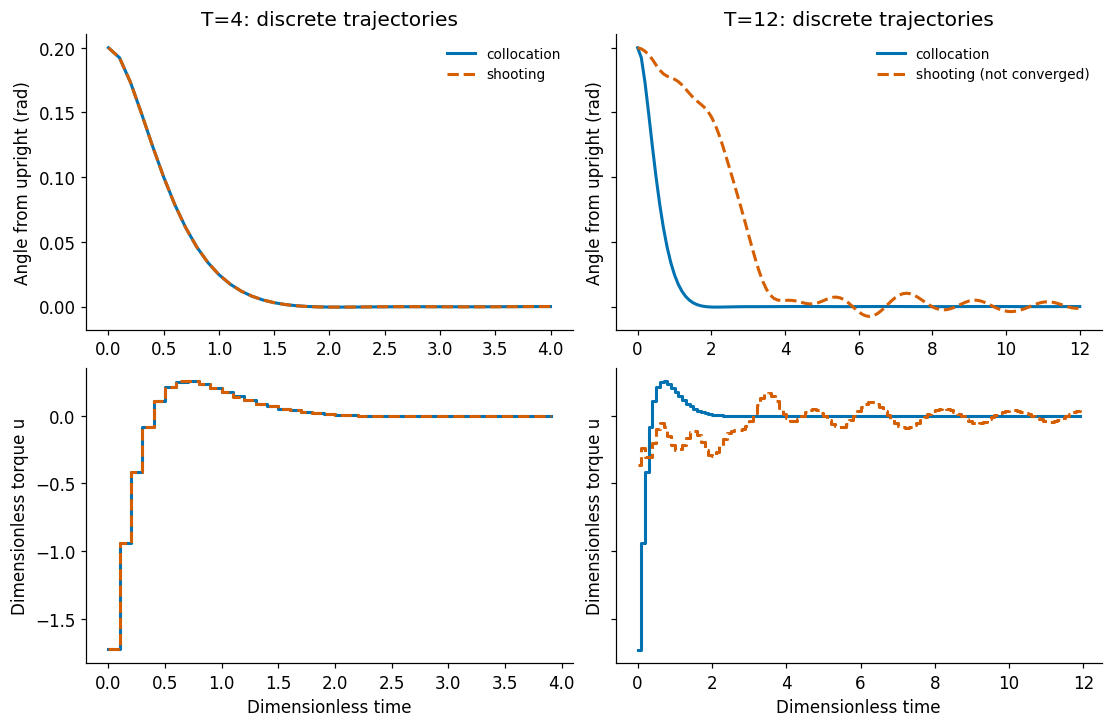

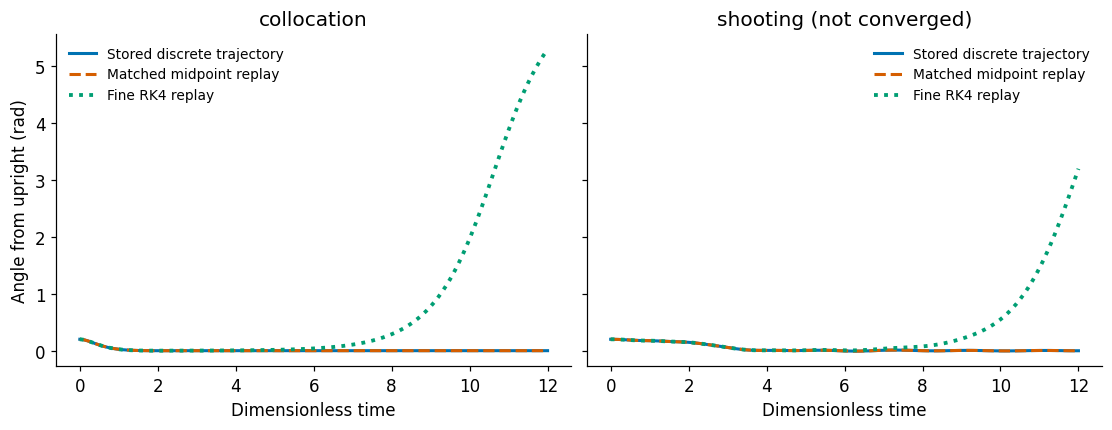

In [12]:
def rk4_replay(u, h=0.1, substeps=20):
    if int(substeps) != substeps or substeps < 1:
        raise ValueError('Use a positive integer substep count.')
    states = np.empty((len(u)+1, 2))
    states[0] = [0.2, 0]
    dt = h/substeps
    for k, control in enumerate(u):
        state = states[k].copy()
        for _ in range(substeps):
            k1 = pendulum_f(state, control)
            k2 = pendulum_f(state+dt*k1/2, control)
            k3 = pendulum_f(state+dt*k2/2, control)
            k4 = pendulum_f(state+dt*k3, control)
            state = state+dt*(k1+2*k2+2*k3+k4)/6
        states[k+1] = state
    return states


print(' T  method         midpoint replay gap    RK4 replay gap    RK4 refinement gap')
for T, experiment in pendulum_runs.items():
    for method, run in experiment['runs'].items():
        run['midpoint_replay'] = pendulum_rollout(run['u'])
        run['rk4_replay'] = rk4_replay(run['u'])
        finer = rk4_replay(run['u'], substeps=40)
        matched_gap = np.max(np.abs(run['midpoint_replay']-run['x']))
        continuous_gap = np.max(np.abs(run['rk4_replay']-run['x']))
        refinement_gap = np.max(np.abs(finer-run['rk4_replay']))
        print(f'{T:2.0f}  {method:12s}      {matched_gap:12.3e}      {continuous_gap:12.3e}      {refinement_gap:12.3e}')
        assert refinement_gap < 1e-4

fig, axes = plt.subplots(2, 2, figsize=(10, 6.5), constrained_layout=True, sharey='row')
for column, T in enumerate([4.0, 12.0]):
    experiment = pendulum_runs[T]
    mesh = np.arange(experiment['problem']['N']+1)*0.1
    for method, style in [('collocation', '-'), ('shooting', '--')]:
        run = experiment['runs'][method]
        label = method+('' if run['result'].success else ' (not converged)')
        axes[0, column].plot(mesh, run['x'][:, 0], style, label=label)
        axes[1, column].step(mesh[:-1], run['u'], where='post', linestyle=style)
    axes[0, column].set(title=f'T={T:g}: discrete trajectories', ylabel='Angle from upright (rad)')
    axes[1, column].set(xlabel='Dimensionless time', ylabel='Dimensionless torque u')
    axes[0, column].legend(fontsize=9)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), constrained_layout=True, sharey=True)
experiment = pendulum_runs[12.0]
mesh = np.arange(experiment['problem']['N']+1)*0.1
for ax, method in zip(axes, ['collocation', 'shooting']):
    run = experiment['runs'][method]
    ax.plot(mesh, run['x'][:, 0], '-', label='Stored discrete trajectory')
    ax.plot(mesh, run['midpoint_replay'][:, 0], '--', label='Matched midpoint replay')
    ax.plot(mesh, run['rk4_replay'][:, 0], ':', linewidth=2.5, label='Fine RK4 replay')
    ax.set(title=method+('' if run['result'].success else ' (not converged)'), xlabel='Dimensionless time')
    ax.legend(fontsize=9)
axes[0].set_ylabel('Angle from upright (rad)')
plt.show()

The stored and midpoint-replayed trajectories should agree closely when local
defects are small. The fine RK4 replay can still drift far away: the continuous
model and the midpoint approximation differ slightly at each step, and the
unstable dynamics amplify those differences. Agreement of the two fine RK4
replays helps distinguish that effect from error in the validation integrator.

At very long horizons, even replay with the matched discretization can amplify
roundoff. Collocation helps compute a discrete plan; accurate execution of an
unstable physical system also requires appropriate discretization and feedback.

In [13]:
for T, experiment in pendulum_runs.items():
    run = experiment['runs']['collocation']
    assert run['result'].success, run['result'].message
    assert run['defect'] < 1e-8
    assert np.max(np.abs(run['u'])) <= 2+1e-8
    assert np.max(np.abs(run['midpoint_replay']-run['x'])) < 1e-5
short = pendulum_runs[4.0]['runs']
assert abs(short['shooting']['cost']-short['collocation']['cost']) < 2e-6
print('All checks passed. Long-horizon shooting failure is deliberately not asserted.')

All checks passed. Long-horizon shooting failure is deliberately not asserted.


## Discussion

1. Explain why a shooting trajectory can have almost zero defects and a poor cost.
2. Which comparison would be confounded if shooting used Euler while collocation used midpoint?
3. How does changing a separate instability from simply adding more variables?
4. What does a small local defect tell you about the continuous pendulum, and what does it leave unchecked?

The conditioning mechanism is also discussed in
[MIT's trajectory-optimization notes](https://underactuated.mit.edu/trajopt.html).
This experiment supports a specific conclusion: retaining states and local
dynamics constraints can improve numerical optimization over long unstable
horizons. It does not establish that collocation always converges faster or
that an optimized open-loop plan will tolerate disturbances.